In [1]:
# CELL 1: Setup
import sys
sys.path.append('..')

import os
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from configs.config import Config
from data.splits import get_datasets
from models.maml_segmentation import MAMLSegmentation, MAMLTrainer
from configs.results_utils import save_kshot_results, print_kshot_results
from configs.model_utils import load_model_weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [2]:
# CELL 2: Data Loading
train_dataset, val_dataset, test_dataset = get_datasets(Config)

print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Val samples:   {len(val_dataset)}")

✓ Splits -> Train: 258, Val: 74, Test: 37
✓ Valid patients: 258/258
✓ Valid patients: 74/74
✓ Valid patients: 37/37
✓ Train samples: 25800
✓ Val samples:   7400


In [3]:
# CELL 3: Create MAML Model + Load Pretrained Weights
model = MAMLSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

checkpoint = torch.load(
    os.path.join(Config.CHECKPOINT_DIR, 'best_model.pth'),
    weights_only=False,
    map_location=Config.DEVICE,
)
state_dict = {k.replace('unet.', '', 1): v 
              for k, v in checkpoint['model_state_dict'].items()}
model.model.load_state_dict(state_dict, strict=False)

print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("✓ Loaded pretrained weights from baseline")

✓ Model parameters: 24,433,668
✓ Loaded pretrained weights from baseline


In [4]:
# CELL 4: MAML Training
trainer = MAMLTrainer(
    model=model,
    config=Config,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
)

history = trainer.train(
    num_tasks=1000,
    k_shot=5,
    n_query=Config.N_QUERY,
)

Starting MAML training
Tasks: 1000, k-shot: 5, n-query: 10
Inner LR: 0.01, Outer LR: 0.001
Inner steps: 5
Device: mps
Task [100/1000] Meta Loss: 0.1123 Inner Loss: 0.0589 Query Loss: 0.1292
  Validation Loss: 0.1921
Task [200/1000] Meta Loss: 0.0947 Inner Loss: 0.0769 Query Loss: 0.1041
  Validation Loss: 0.1577
Task [300/1000] Meta Loss: 0.0830 Inner Loss: 0.0810 Query Loss: 0.0784
  Validation Loss: 0.1694
Task [400/1000] Meta Loss: 0.1131 Inner Loss: 0.1273 Query Loss: 0.0952
  Validation Loss: 0.2119
Task [500/1000] Meta Loss: 0.1192 Inner Loss: 0.3209 Query Loss: 0.1164
  Validation Loss: 0.1914
  Saved MAML checkpoint: /Users/yuzheli/Desktop/Grad School/CS7150/Final Project/UNet-FewShot/checkpoints/maml_task500.pth
Task [600/1000] Meta Loss: 0.0727 Inner Loss: 0.0634 Query Loss: 0.0815
  Validation Loss: 0.1770
Task [700/1000] Meta Loss: 0.0766 Inner Loss: 0.2760 Query Loss: 0.0781
  Validation Loss: 0.2013
Task [800/1000] Meta Loss: 0.1184 Inner Loss: 0.1293 Query Loss: 0.1194
 

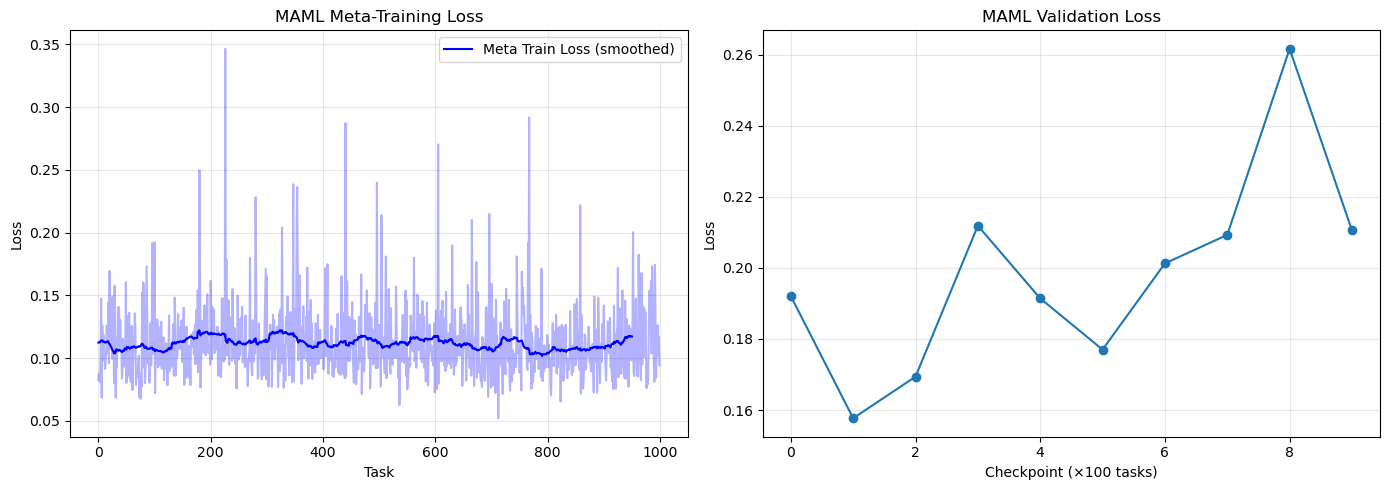

In [5]:
# CELL 5: Training Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['meta_train_loss'], alpha=0.3, color='blue')
# Smoothed version (rolling average)
window = 50
if len(history['meta_train_loss']) >= window:
    smoothed = np.convolve(history['meta_train_loss'],
                           np.ones(window)/window, mode='valid')
    axes[0].plot(smoothed, color='blue', label='Meta Train Loss (smoothed)')
axes[0].set_xlabel('Task')
axes[0].set_ylabel('Loss')
axes[0].set_title('MAML Meta-Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['meta_val_loss'], marker='o')
axes[1].set_xlabel('Checkpoint (×100 tasks)')
axes[1].set_ylabel('Loss')
axes[1].set_title('MAML Validation Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'maml_training_curve.png'), dpi=150)
plt.show()

In [6]:
# CELL 6: K-Shot Evaluation (Dice + HD95)
k_shot_results = trainer.evaluate_k_shot(
    k_values=Config.K_SHOT_VALUES,
    num_tasks=50,
    compute_hd95=True,
)

# Print summary
print(f"\n{'='*60}")
print("MAML K-SHOT RESULTS")
print(f"{'='*60}")
for k in Config.K_SHOT_VALUES:
    r = k_shot_results[k]
    print(f"  k={k:>2}: Dice = {r['mean']:.4f} ± {r['std']:.4f}  |  "
          f"HD95 = {r['hd95_mean']:.2f} ± {r['hd95_std']:.2f} px")
print(f"{'='*60}")

save_kshot_results(k_shot_results, Config.RESULTS_DIR, 'maml_kshot_results.json')


Evaluating MAML at k=1...
  Task 5/50: DICE = 0.8570 | HD95 = 7.67 px
  Task 10/50: DICE = 0.6883 | HD95 = 23.90 px
  Task 15/50: DICE = 0.8791 | HD95 = 6.58 px
  Task 20/50: DICE = 0.7088 | HD95 = 1.88 px
  Task 25/50: DICE = 0.7109 | HD95 = 8.20 px
  Task 30/50: DICE = 0.6372 | HD95 = 12.86 px
  Task 35/50: DICE = 0.6998 | HD95 = 7.28 px
  Task 40/50: DICE = 0.8145 | HD95 = 10.36 px
  Task 45/50: DICE = 0.7246 | HD95 = 5.36 px
  Task 50/50: DICE = 0.8049 | HD95 = 16.45 px
✓ k=1: DICE = 0.7745 ± 0.0700  |  HD95 = 9.55 ± 7.85 px

Evaluating MAML at k=5...
  Task 5/50: DICE = 0.7958 | HD95 = 0.58 px
  Task 10/50: DICE = 0.8535 | HD95 = 2.56 px
  Task 15/50: DICE = 0.7571 | HD95 = 2.83 px
  Task 20/50: DICE = 0.7787 | HD95 = 4.63 px
  Task 25/50: DICE = 0.8477 | HD95 = 1.24 px
  Task 30/50: DICE = 0.8973 | HD95 = 0.41 px
  Task 35/50: DICE = 0.7675 | HD95 = 1.79 px
  Task 40/50: DICE = 0.8166 | HD95 = 1.46 px
  Task 45/50: DICE = 0.8890 | HD95 = 0.29 px
  Task 50/50: DICE = 0.8362 | HD9

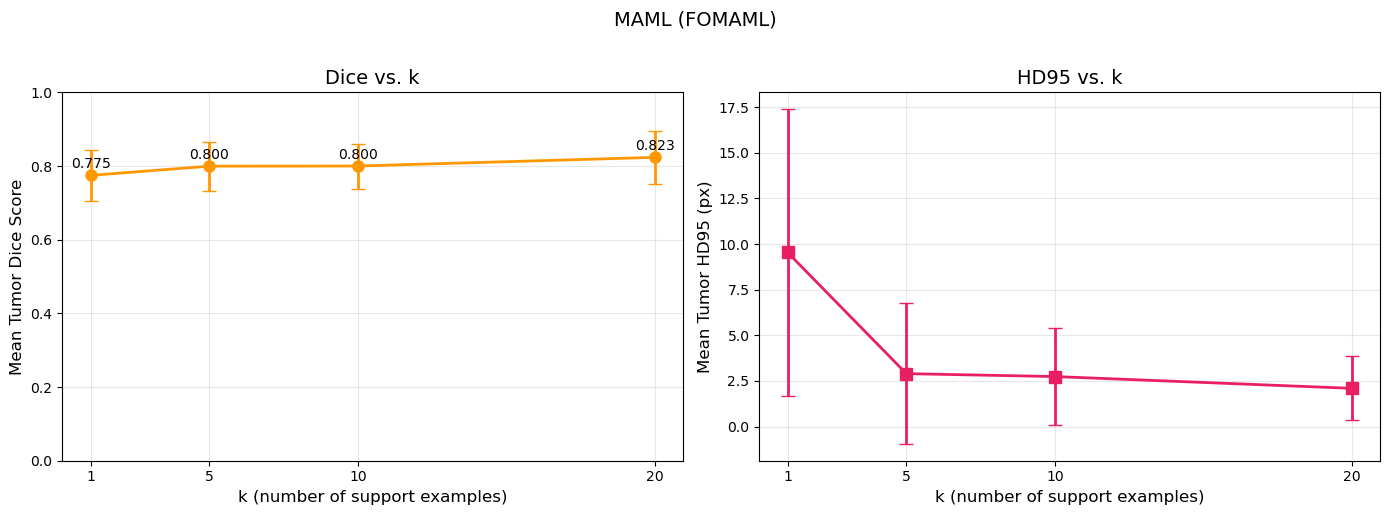

In [7]:
# CELL 7: Learning Curves (Dice + HD95)
k_values = Config.K_SHOT_VALUES
means = [k_shot_results[k]['mean'] for k in k_values]
stds = [k_shot_results[k]['std'] for k in k_values]
hd_means = [k_shot_results[k]['hd95_mean'] for k in k_values]
hd_stds = [k_shot_results[k]['hd95_std'] for k in k_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dice curve
ax1.errorbar(k_values, means, yerr=stds, marker='o', capsize=5,
             linewidth=2, markersize=8, color='#FF9800')
ax1.set_xlabel('k (number of support examples)', fontsize=12)
ax1.set_ylabel('Mean Tumor Dice Score', fontsize=12)
ax1.set_title('Dice vs. k', fontsize=14)
ax1.set_xticks(k_values)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

for k, dice in zip(k_values, means):
    ax1.text(k, dice + 0.02, f'{dice:.3f}', ha='center', fontsize=10)

# HD95 curve
ax2.errorbar(k_values, hd_means, yerr=hd_stds, marker='s', capsize=5,
             linewidth=2, markersize=8, color='#E91E63')
ax2.set_xlabel('k (number of support examples)', fontsize=12)
ax2.set_ylabel('Mean Tumor HD95 (px)', fontsize=12)
ax2.set_title('HD95 vs. k', fontsize=14)
ax2.set_xticks(k_values)
ax2.grid(True, alpha=0.3)

plt.suptitle('MAML (FOMAML)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'maml_kshot_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()